In [1]:
import numpy as np
import pandas as  pd 
import matplotlib.pyplot as plt 

%matplotlib inline

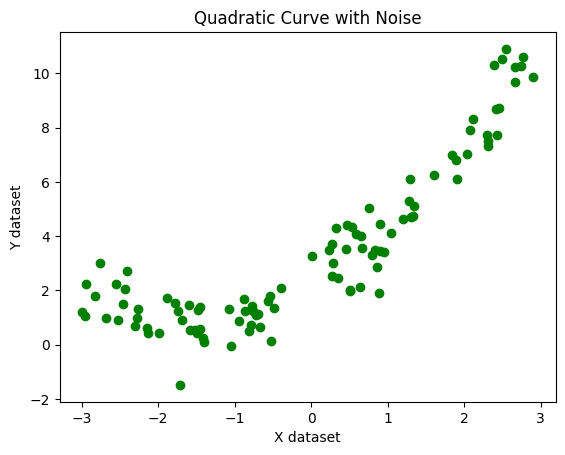

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate dataset
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.randn(100, 1)

# Scatter plot
plt.scatter(X, y, color='g')
plt.xlabel("X dataset")
plt.ylabel("Y dataset")
plt.title("Quadratic Curve with Noise")
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Checking the performance of linear regression

In [4]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [5]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
# Checking the r2 score
from sklearn.metrics import r2_score
score = r2_score(y_test,regression_1.predict(X_test))
print(f"R2 score for simple linear regression is : {score}")

R2 score for simple linear regression is : 0.7694017918342086


Text(0, 0.5, 'Y dataset')

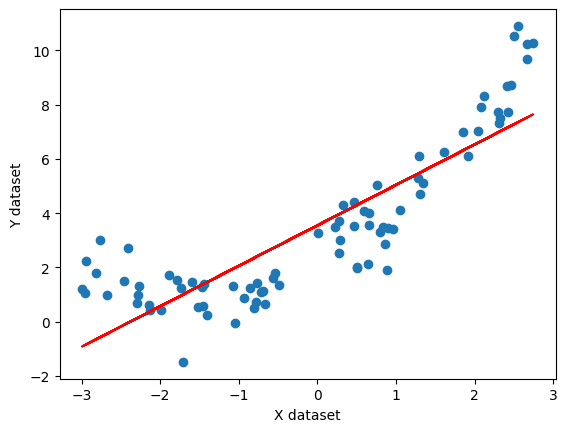

In [7]:
# Visualizing the best fit line
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

Even though the relationship between X and Y is non-linear, the linear regression still finds a linear best fit line which created a room for a lot of error or very less accuracy

### Using polynomial regression

In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=True)

In [13]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [14]:
regression_2 = LinearRegression()
regression_2.fit(X_train_poly,y_train)

y_pred = regression_2.predict(X_test_poly)
score = r2_score(y_test,y_pred)

print(f"R2 score using polynomical regression is : {score}")

R2 score using polynomical regression is : 0.9532279657173026


Text(0, 0.5, 'Y')

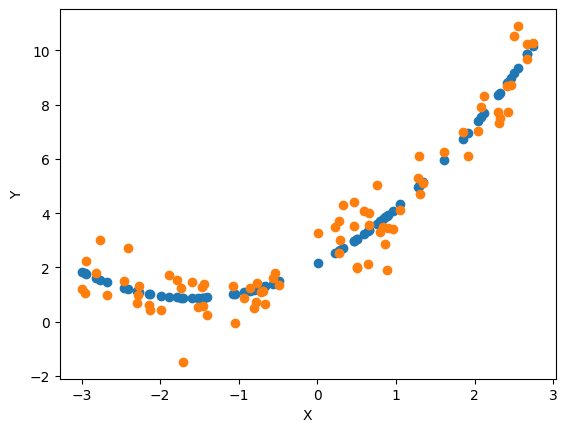

In [15]:
# Plot 
plt.scatter(X_train,regression_2.predict(X_train_poly))
plt.scatter(X_train,y_train)
plt.xlabel("X")
plt.ylabel("Y")


When we used polynomial features, the data is converted to three featured one and upon applying linear regression on that, we were able to get the curve that is closer to the actual data points

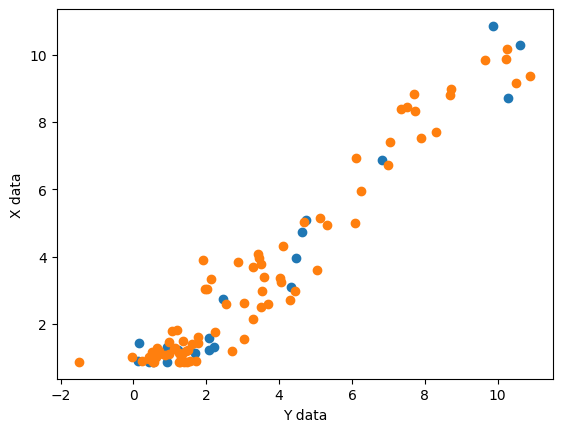

In [21]:
Y_pred_test = regression_2.predict(X_test_poly)
Y_pred_train = regression_2.predict(X_train_poly)
plt.scatter(y_test,Y_pred_test)
plt.scatter(y_train,Y_pred_train)

plt.xlabel("Y data")
plt.ylabel("X data")

plt.show()

### Polynomial regression pipeline

In [22]:
from sklearn.pipeline import Pipeline

In [23]:
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)
    poly_features = PolynomialFeatures(degree=degree,include_bias=True)
    lin_regression = LinearRegression()

    poly_regression = Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_regression)
    ])

    poly_regression.fit(X_train,y_train)
    y_pred_new = poly_regression.predict(X_new)

    plt.plot(X_new,y_pred_new,'r',label="Degree "+str(degree),linewidth=3)
    plt.plot(X_train,y_train,"b.",linewidth=3)
    plt.plot(X_test,y_test,"g.",linewidth=3)
    plt.legend(loc = "upper left")
    plt.xlabel("X")
    plt.ylabel("y")

    plt.axis([-4,4,0,10])
    plt.show()

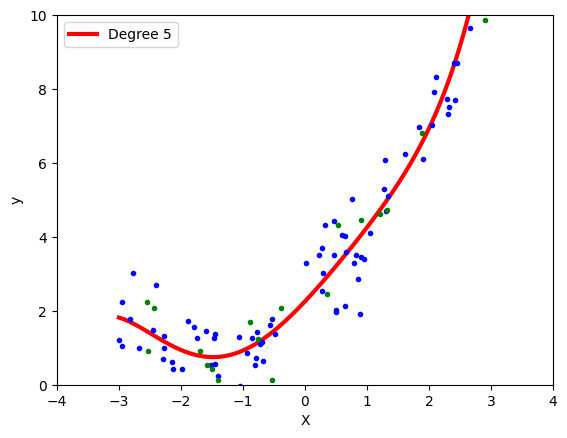

In [24]:
poly_regression(5)

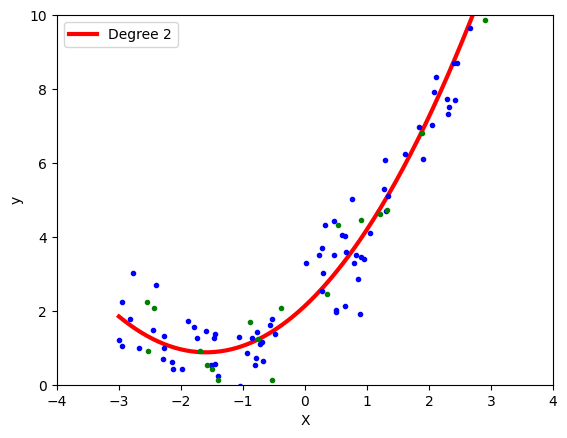

In [25]:
poly_regression(2)